In [1]:
# CELL 1 — Install dependencies
# Dataset source: https://challenge.isic-archive.com/data/#2018
# Direct S3 links — no login or API key required
!pip install -q albumentations

In [2]:
# CELL 2 — Imports & reproducibility seed
import os, random, zipfile, glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

import albumentations as A
from albumentations.pytorch import ToTensorV2

from sklearn.metrics import (confusion_matrix, ConfusionMatrixDisplay,
                             precision_score, recall_score, f1_score)

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)

Device: cuda


In [3]:
# CELL 3 — Download ISIC 2018 Task-1 dataset (official S3 links, no login needed)
#
# Official dataset page : https://challenge.isic-archive.com/data/#2018
# We use the Validation split (100 images + masks, ~229 MB total) for fast Colab runtime.
# For full training (2594 images, 10.4 GB) replace URLs with the Training links below.
#
# Training images  : https://isic-archive.s3.amazonaws.com/challenges/2018/ISIC2018_Task1-2_Training_Input.zip
# Training masks   : https://isic-archive.s3.amazonaws.com/challenges/2018/ISIC2018_Task1_Training_GroundTruth.zip
# Validation imgs  : https://isic-archive.s3.amazonaws.com/challenges/2018/ISIC2018_Task1-2_Validation_Input.zip
# Validation masks : https://isic-archive.s3.amazonaws.com/challenges/2018/ISIC2018_Task1_Validation_GroundTruth.zip
# Test images      : https://isic-archive.s3.amazonaws.com/challenges/2018/ISIC2018_Task1-2_Test_Input.zip
# Test masks       : https://isic-archive.s3.amazonaws.com/challenges/2018/ISIC2018_Task1_Test_GroundTruth.zip

IMG_ZIP  = "/content/imgs.zip"
MASK_ZIP = "/content/masks.zip"
IMG_DIR  = "/content/isic_images"
MASK_DIR = "/content/isic_masks"
os.makedirs(IMG_DIR,  exist_ok=True)
os.makedirs(MASK_DIR, exist_ok=True)

IMG_URL  = "https://isic-archive.s3.amazonaws.com/challenges/2018/ISIC2018_Task1-2_Validation_Input.zip"
MASK_URL = "https://isic-archive.s3.amazonaws.com/challenges/2018/ISIC2018_Task1_Validation_GroundTruth.zip"

print("Downloading images (~228 MB) ...")
os.system(f"wget -q --show-progress -O {IMG_ZIP}  '{IMG_URL}'")
print("Downloading masks  (~742 KB) ...")
os.system(f"wget -q --show-progress -O {MASK_ZIP} '{MASK_URL}'")

print("Extracting ...")
with zipfile.ZipFile(IMG_ZIP,  "r") as z: z.extractall("/content/imgs_raw")
with zipfile.ZipFile(MASK_ZIP, "r") as z: z.extractall("/content/masks_raw")

# Copy jpegs and pngs into flat directories
import shutil
for f in glob.glob("/content/imgs_raw/**/*.jpg",  recursive=True): shutil.copy(f, IMG_DIR)
for f in glob.glob("/content/imgs_raw/**/*.jpeg", recursive=True): shutil.copy(f, IMG_DIR)
for f in glob.glob("/content/masks_raw/**/*.png", recursive=True): shutil.copy(f, MASK_DIR)

print(f"Images  in {IMG_DIR}  : {len(os.listdir(IMG_DIR))}")
print(f"Masks   in {MASK_DIR} : {len(os.listdir(MASK_DIR))}")

Extracting ...
Images  in /content/isic_images  : 100
Masks   in /content/isic_masks : 100


In [4]:
# CELL 4 — Build matched ID list & train/val/test split
img_stems  = {os.path.splitext(os.path.basename(f))[0]
              for f in glob.glob(f"{IMG_DIR}/*.jpg") + glob.glob(f"{IMG_DIR}/*.jpeg")}
mask_stems = {os.path.splitext(os.path.basename(f))[0].replace("_segmentation", "")
              for f in glob.glob(f"{MASK_DIR}/*.png")}

valid_ids = sorted(img_stems & mask_stems)
print(f"Matched image-mask pairs: {len(valid_ids)}")

random.shuffle(valid_ids)
n         = len(valid_ids)
train_ids = valid_ids[:int(0.70 * n)]
val_ids   = valid_ids[int(0.70 * n):int(0.85 * n)]
test_ids  = valid_ids[int(0.85 * n):]
print(f"Train: {len(train_ids)} | Val: {len(val_ids)} | Test: {len(test_ids)}")

Matched image-mask pairs: 100
Train: 70 | Val: 15 | Test: 15


In [5]:
# CELL 5 — Augmentation pipelines
IMG_SIZE = 256

train_transforms = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.3),
    A.RandomRotate90(p=0.4),
    A.ShiftScaleRotate(shift_limit=0.05, scale_limit=0.1, rotate_limit=20, p=0.4),
    A.RandomBrightnessContrast(brightness_limit=0.2, contrast_limit=0.2, p=0.4),
    A.GaussNoise(p=0.2),
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2(),
])

val_transforms = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2(),
])
print("Augmentation pipelines ready.")

/usr/local/lib/python3.12/dist-packages/albumentations/core/validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)


Augmentation pipelines ready.


In [6]:
# CELL 6 — Dataset class
class ISICDataset(Dataset):
    def __init__(self, ids, img_dir, mask_dir, transform=None):
        self.ids       = ids
        self.img_dir   = img_dir
        self.mask_dir  = mask_dir
        self.transform = transform

    def __len__(self):
        return len(self.ids)

    def __getitem__(self, idx):
        iid  = self.ids[idx]
        # support both .jpg and .jpeg
        img_path = (os.path.join(self.img_dir, f"{iid}.jpg")
                    if os.path.exists(os.path.join(self.img_dir, f"{iid}.jpg"))
                    else os.path.join(self.img_dir, f"{iid}.jpeg"))
        mask_path = os.path.join(self.mask_dir, f"{iid}_segmentation.png")

        image = np.array(Image.open(img_path).convert("RGB"))
        mask  = np.array(Image.open(mask_path).convert("L"))
        mask  = (mask > 127).astype(np.float32)

        if self.transform:
            aug   = self.transform(image=image, mask=mask)
            image = aug["image"]
            mask  = aug["mask"].unsqueeze(0)
        return image, mask

train_ds = ISICDataset(train_ids, IMG_DIR, MASK_DIR, train_transforms)
val_ds   = ISICDataset(val_ids,   IMG_DIR, MASK_DIR, val_transforms)
test_ds  = ISICDataset(test_ids,  IMG_DIR, MASK_DIR, val_transforms)

train_loader = DataLoader(train_ds, batch_size=8, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=8, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=8, shuffle=False, num_workers=2, pin_memory=True)

print(f"Batches — Train: {len(train_loader)} | Val: {len(val_loader)} | Test: {len(test_loader)}")

Batches — Train: 9 | Val: 2 | Test: 2


In [7]:
# CELL 7 — Model: Attention Residual U-Net
#
# Architecture:
#   - Residual double-conv blocks (encoder + decoder)
#   - Additive attention gates on every skip connection (Oktay et al., 2018)
#   - 4-level encoder/decoder with max-pool downsampling
#   - Transposed-conv upsampling
#   - ~31 M parameters

class ResidualBlock(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
        )
        self.proj = (nn.Conv2d(in_ch, out_ch, 1, bias=False)
                     if in_ch != out_ch else nn.Identity())
        self.act  = nn.ReLU(inplace=True)

    def forward(self, x):
        return self.act(self.conv(x) + self.proj(x))


class AttentionGate(nn.Module):
    def __init__(self, g_ch, x_ch, inter_ch):
        super().__init__()
        self.Wg  = nn.Conv2d(g_ch,    inter_ch, 1, bias=True)
        self.Wx  = nn.Conv2d(x_ch,    inter_ch, 1, bias=True)
        self.psi = nn.Sequential(nn.Conv2d(inter_ch, 1, 1, bias=True), nn.Sigmoid())

    def forward(self, g, x):
        g_up = F.interpolate(self.Wg(g), size=x.shape[2:], mode="bilinear", align_corners=False)
        att  = self.psi(F.relu(g_up + self.Wx(x), inplace=True))
        return x * att


class AttResUNet(nn.Module):
    def __init__(self, in_ch=3, out_ch=1, base=64):
        super().__init__()
        b = base
        self.enc1 = ResidualBlock(in_ch, b)
        self.enc2 = ResidualBlock(b,   b*2)
        self.enc3 = ResidualBlock(b*2, b*4)
        self.enc4 = ResidualBlock(b*4, b*8)
        self.bottleneck = ResidualBlock(b*8, b*16)
        self.pool = nn.MaxPool2d(2)
        self.att4 = AttentionGate(b*16, b*8,  b*8)
        self.att3 = AttentionGate(b*8,  b*4,  b*4)
        self.att2 = AttentionGate(b*4,  b*2,  b*2)
        self.att1 = AttentionGate(b*2,  b,    b)
        self.up4  = nn.ConvTranspose2d(b*16, b*8, 2, stride=2)
        self.up3  = nn.ConvTranspose2d(b*8,  b*4, 2, stride=2)
        self.up2  = nn.ConvTranspose2d(b*4,  b*2, 2, stride=2)
        self.up1  = nn.ConvTranspose2d(b*2,  b,   2, stride=2)
        self.dec4 = ResidualBlock(b*16, b*8)
        self.dec3 = ResidualBlock(b*8,  b*4)
        self.dec2 = ResidualBlock(b*4,  b*2)
        self.dec1 = ResidualBlock(b*2,  b)
        self.out_conv = nn.Conv2d(b, out_ch, 1)

    def forward(self, x):
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool(e1))
        e3 = self.enc3(self.pool(e2))
        e4 = self.enc4(self.pool(e3))
        bn = self.bottleneck(self.pool(e4))
        d4 = self.dec4(torch.cat([self.up4(bn), self.att4(bn, e4)], dim=1))
        d3 = self.dec3(torch.cat([self.up3(d4), self.att3(d4, e3)], dim=1))
        d2 = self.dec2(torch.cat([self.up2(d3), self.att2(d3, e2)], dim=1))
        d1 = self.dec1(torch.cat([self.up1(d2), self.att1(d2, e1)], dim=1))
        return self.out_conv(d1)

model = AttResUNet(in_ch=3, out_ch=1, base=64).to(DEVICE)
total_params = sum(p.numel() for p in model.parameters())
train_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total parameters  : {total_params:,}")
print(f"Trainable params  : {train_params:,}")

Total parameters  : 33,477,829
Trainable params  : 33,477,829


In [8]:
# CELL 8 — Combined BCE + Dice loss, optimizer, scheduler
class BCEDiceLoss(nn.Module):
    def __init__(self, bce_weight=0.4):
        super().__init__()
        self.bce_w = bce_weight
        self.bce   = nn.BCEWithLogitsLoss()

    def forward(self, logits, targets):
        bce_val = self.bce(logits, targets)
        probs   = torch.sigmoid(logits)
        smooth  = 1e-6
        inter   = (probs * targets).sum(dim=(2, 3))
        union   = probs.sum(dim=(2, 3)) + targets.sum(dim=(2, 3))
        dice    = 1 - (2 * inter + smooth) / (union + smooth)
        return self.bce_w * bce_val + (1 - self.bce_w) * dice.mean()

criterion = BCEDiceLoss(bce_weight=0.4)
optimizer = torch.optim.AdamW(model.parameters(), lr=3e-4, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=30, eta_min=1e-6)
print("Loss, optimizer, and scheduler ready.")

Loss, optimizer, and scheduler ready.


In [9]:
# CELL 9 — Metric helper functions
def dice_score(pred, target, threshold=0.5, smooth=1e-6):
    pred  = (torch.sigmoid(pred) > threshold).float()
    inter = (pred * target).sum(dim=(2, 3))
    union = pred.sum(dim=(2, 3)) + target.sum(dim=(2, 3))
    return ((2 * inter + smooth) / (union + smooth)).mean().item()

def iou_score(pred, target, threshold=0.5, smooth=1e-6):
    pred  = (torch.sigmoid(pred) > threshold).float()
    inter = (pred * target).sum(dim=(2, 3))
    union = pred.sum(dim=(2, 3)) + target.sum(dim=(2, 3)) - inter
    return ((inter + smooth) / (union + smooth)).mean().item()

print("Metric functions defined.")

Metric functions defined.


In [10]:
# CELL 10 — Training loop (30 epochs)
EPOCHS    = 30
history   = {"train_loss": [], "val_loss": [], "val_dice": [], "val_iou": []}
best_dice = 0.0
best_path = "/content/best_att_resunet.pth"

for epoch in range(1, EPOCHS + 1):
    # --- Train ---
    model.train()
    t_loss = 0.0
    for imgs, masks in train_loader:
        imgs, masks = imgs.to(DEVICE), masks.to(DEVICE)
        optimizer.zero_grad()
        loss = criterion(model(imgs), masks)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        t_loss += loss.item()

    # --- Validate ---
    model.eval()
    v_loss, v_dice, v_iou = 0.0, 0.0, 0.0
    with torch.no_grad():
        for imgs, masks in val_loader:
            imgs, masks = imgs.to(DEVICE), masks.to(DEVICE)
            logits = model(imgs)
            v_loss += criterion(logits, masks).item()
            v_dice += dice_score(logits, masks)
            v_iou  += iou_score(logits, masks)

    t_loss /= len(train_loader)
    v_loss /= len(val_loader)
    v_dice /= len(val_loader)
    v_iou  /= len(val_loader)

    history["train_loss"].append(t_loss)
    history["val_loss"].append(v_loss)
    history["val_dice"].append(v_dice)
    history["val_iou"].append(v_iou)
    scheduler.step()

    tag = ""
    if v_dice > best_dice:
        best_dice = v_dice
        torch.save(model.state_dict(), best_path)
        tag = "  <-- saved"

    print(f"Epoch {epoch:02d}/{EPOCHS}  "
          f"Train Loss: {t_loss:.4f}  "
          f"Val Loss: {v_loss:.4f}  "
          f"Dice: {v_dice:.4f}  "
          f"IoU: {v_iou:.4f}{tag}")

print(f"\nBest validation Dice: {best_dice:.4f}")

Epoch 01/30  Train Loss: 0.5837  Val Loss: 0.6677  Dice: 0.4959  IoU: 0.3824  <-- saved
Epoch 02/30  Train Loss: 0.5113  Val Loss: 0.5919  Dice: 0.5576  IoU: 0.4333  <-- saved
Epoch 03/30  Train Loss: 0.4955  Val Loss: 1.2051  Dice: 0.0345  IoU: 0.0227
Epoch 04/30  Train Loss: 0.4534  Val Loss: 0.4705  Dice: 0.6957  IoU: 0.5883  <-- saved
Epoch 05/30  Train Loss: 0.3970  Val Loss: 0.3598  Dice: 0.7958  IoU: 0.7088  <-- saved
Epoch 06/30  Train Loss: 0.3928  Val Loss: 1.1997  Dice: 0.4186  IoU: 0.3040
Epoch 07/30  Train Loss: 0.3795  Val Loss: 0.3250  Dice: 0.7697  IoU: 0.6552
Epoch 08/30  Train Loss: 0.3167  Val Loss: 0.3384  Dice: 0.7512  IoU: 0.6301
Epoch 09/30  Train Loss: 0.3233  Val Loss: 0.3927  Dice: 0.7076  IoU: 0.5852
Epoch 10/30  Train Loss: 0.3208  Val Loss: 0.5044  Dice: 0.6588  IoU: 0.5415
Epoch 11/30  Train Loss: 0.3477  Val Loss: 0.3801  Dice: 0.6887  IoU: 0.5672
Epoch 12/30  Train Loss: 0.2921  Val Loss: 0.3193  Dice: 0.7852  IoU: 0.6776
Epoch 13/30  Train Loss: 0.3113 

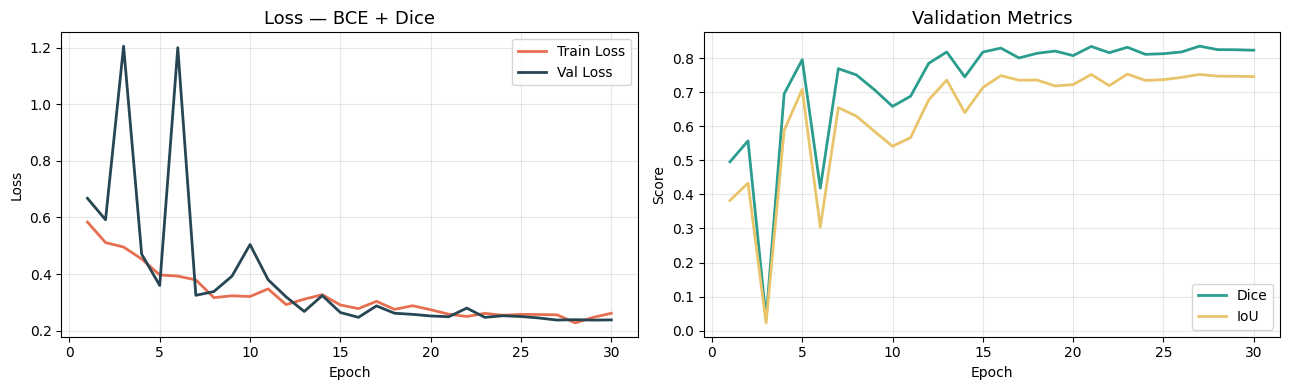

In [11]:
# CELL 11 — Learning curves
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
epochs_x  = range(1, EPOCHS + 1)

axes[0].plot(epochs_x, history["train_loss"], label="Train Loss", color="#E76F51", linewidth=2)
axes[0].plot(epochs_x, history["val_loss"],   label="Val Loss",   color="#264653", linewidth=2)
axes[0].set_title("Loss — BCE + Dice", fontsize=13)
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss")
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(epochs_x, history["val_dice"], label="Dice", color="#2A9D8F", linewidth=2)
axes[1].plot(epochs_x, history["val_iou"],  label="IoU",  color="#E9C46A", linewidth=2)
axes[1].set_title("Validation Metrics", fontsize=13)
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Score")
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig("/content/learning_curves.png", dpi=150)
plt.show()

In [12]:
# CELL 12 — Test-set evaluation
model.load_state_dict(torch.load(best_path))
model.eval()

all_preds, all_masks_flat = [], []
test_dice, test_iou = 0.0, 0.0

with torch.no_grad():
    for imgs, masks in test_loader:
        imgs, masks = imgs.to(DEVICE), masks.to(DEVICE)
        logits = model(imgs)
        test_dice += dice_score(logits, masks)
        test_iou  += iou_score(logits, masks)
        preds = (torch.sigmoid(logits) > 0.5).cpu().numpy().astype(np.uint8).flatten()
        tgts  = masks.cpu().numpy().astype(np.uint8).flatten()
        all_preds.extend(preds)
        all_masks_flat.extend(tgts)

test_dice /= len(test_loader)
test_iou  /= len(test_loader)
all_preds      = np.array(all_preds)
all_masks_flat = np.array(all_masks_flat)

prec = precision_score(all_masks_flat, all_preds, zero_division=0)
rec  = recall_score(all_masks_flat, all_preds, zero_division=0)
f1   = f1_score(all_masks_flat, all_preds, zero_division=0)

print("=" * 42)
print("  TEST SET RESULTS")
print("=" * 42)
print(f"  Dice Coefficient : {test_dice:.4f}")
print(f"  IoU  (Jaccard)   : {test_iou:.4f}")
print(f"  Precision        : {prec:.4f}")
print(f"  Recall           : {rec:.4f}")
print(f"  F1-Score         : {f1:.4f}")
print("=" * 42)

  TEST SET RESULTS
  Dice Coefficient : 0.8649
  IoU  (Jaccard)   : 0.7876
  Precision        : 0.8454
  Recall           : 0.9163
  F1-Score         : 0.8794


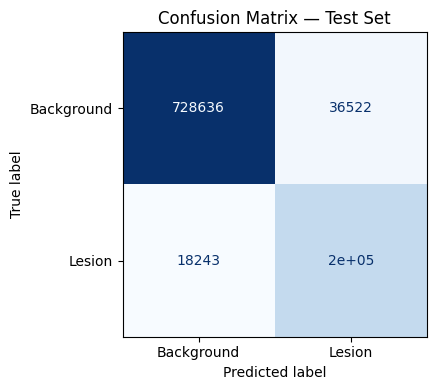

In [13]:
# CELL 13 — Confusion matrix
cm   = confusion_matrix(all_masks_flat, all_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=["Background", "Lesion"])
fig, ax = plt.subplots(figsize=(5, 4))
disp.plot(ax=ax, colorbar=False, cmap="Blues")
ax.set_title("Confusion Matrix — Test Set", fontsize=12)
plt.tight_layout()
plt.savefig("/content/confusion_matrix.png", dpi=150)
plt.show()

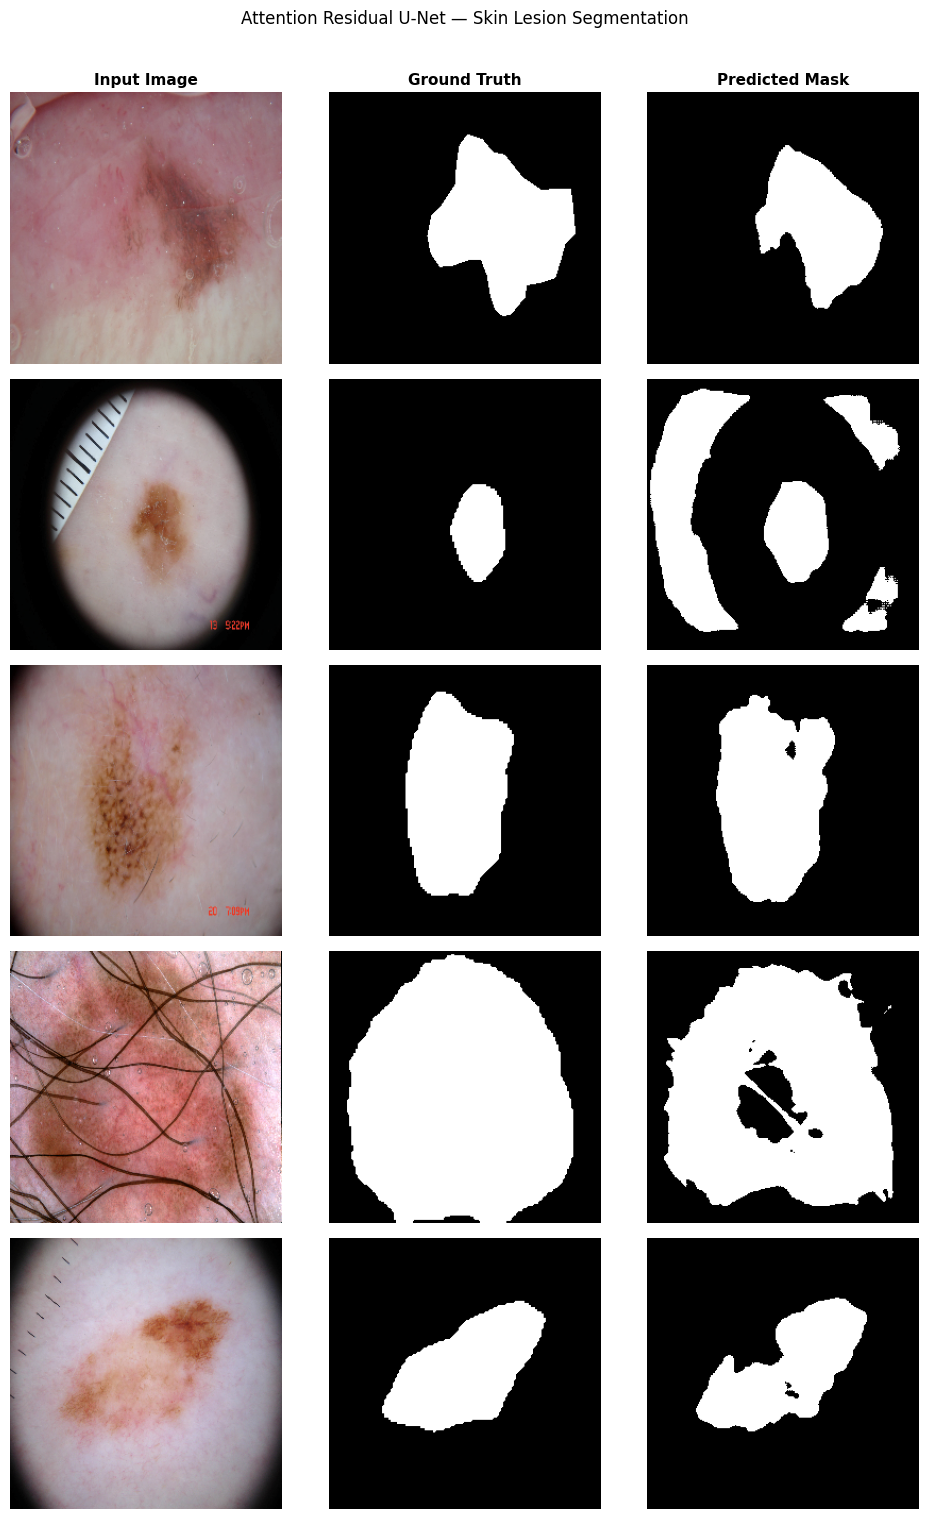

In [14]:
# CELL 14 — Qualitative prediction samples
MEAN = np.array([0.485, 0.456, 0.406])
STD  = np.array([0.229, 0.224, 0.225])

def denorm(tensor):
    img = tensor.cpu().numpy().transpose(1, 2, 0)
    return np.clip(img * STD + MEAN, 0, 1)

model.eval()
sample_imgs, sample_masks = next(iter(test_loader))
sample_imgs = sample_imgs.to(DEVICE)

with torch.no_grad():
    sample_preds = (torch.sigmoid(model(sample_imgs)) > 0.5).squeeze(1).cpu().numpy()

n_show = min(5, len(sample_imgs))
fig, axes = plt.subplots(n_show, 3, figsize=(10, 3 * n_show))
for col, t in enumerate(["Input Image", "Ground Truth", "Predicted Mask"]):
    axes[0, col].set_title(t, fontsize=11, fontweight="bold")

for row in range(n_show):
    axes[row, 0].imshow(denorm(sample_imgs[row].cpu()))
    axes[row, 1].imshow(sample_masks[row, 0].numpy(), cmap="gray")
    axes[row, 2].imshow(sample_preds[row], cmap="gray")
    for col in range(3): axes[row, col].axis("off")

plt.suptitle("Attention Residual U-Net — Skin Lesion Segmentation", fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig("/content/prediction_samples.png", dpi=150, bbox_inches="tight")
plt.show()

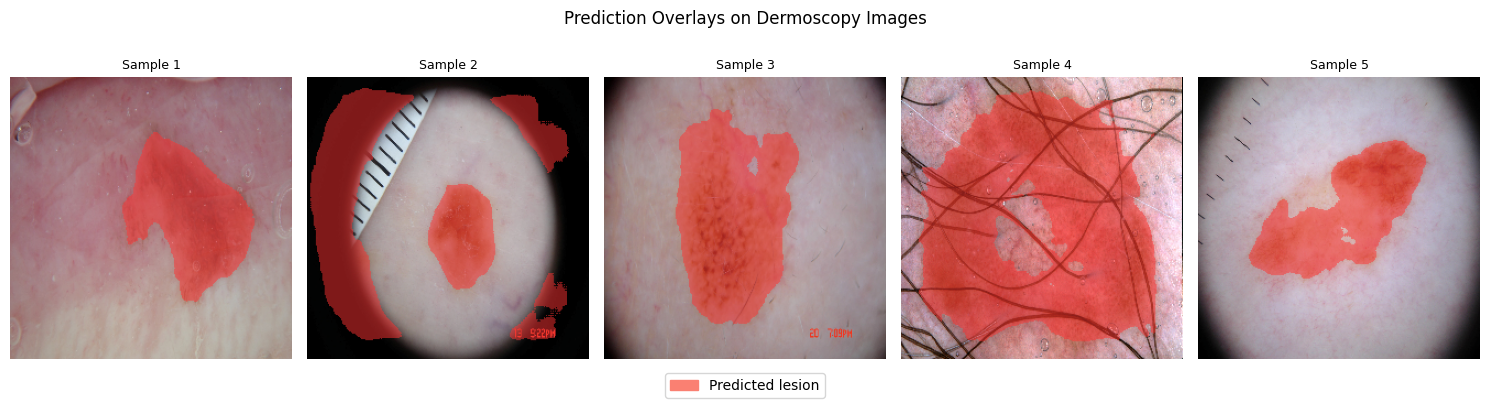

In [15]:
# CELL 15 — Overlay visualisation (predicted lesion in red)
fig, axes = plt.subplots(1, n_show, figsize=(15, 4))
for i in range(n_show):
    raw     = denorm(sample_imgs[i].cpu())
    overlay = raw.copy()
    overlay[sample_preds[i].astype(bool)] = (
        overlay[sample_preds[i].astype(bool)] * 0.5 + np.array([1, 0.2, 0.2]) * 0.5
    )
    axes[i].imshow(overlay); axes[i].axis("off"); axes[i].set_title(f"Sample {i+1}", fontsize=9)

fig.legend(handles=[mpatches.Patch(color="salmon", label="Predicted lesion")],
           loc="lower center", fontsize=10)
plt.suptitle("Prediction Overlays on Dermoscopy Images", fontsize=12)
plt.tight_layout()
plt.savefig("/content/overlay_predictions.png", dpi=150, bbox_inches="tight")
plt.show()

In [16]:
# CELL 16 — Parameter count table
layer_data = []
for name, module in model.named_modules():
    params = sum(p.numel() for p in module.parameters(recurse=False))
    if params > 0:
        layer_data.append({"Layer": name, "Parameters": params})

df_params = pd.DataFrame(layer_data)
df_params["% of Total"] = (df_params["Parameters"] / total_params * 100).round(2)
print(df_params.to_string(index=False))
print(f"\nTotal trainable parameters: {train_params:,}")

            Layer  Parameters  % of Total
      enc1.conv.0        1728        0.01
      enc1.conv.1         128        0.00
      enc1.conv.3       36864        0.11
      enc1.conv.4         128        0.00
        enc1.proj         192        0.00
      enc2.conv.0       73728        0.22
      enc2.conv.1         256        0.00
      enc2.conv.3      147456        0.44
      enc2.conv.4         256        0.00
        enc2.proj        8192        0.02
      enc3.conv.0      294912        0.88
      enc3.conv.1         512        0.00
      enc3.conv.3      589824        1.76
      enc3.conv.4         512        0.00
        enc3.proj       32768        0.10
      enc4.conv.0     1179648        3.52
      enc4.conv.1        1024        0.00
      enc4.conv.3     2359296        7.05
      enc4.conv.4        1024        0.00
        enc4.proj      131072        0.39
bottleneck.conv.0     4718592       14.09
bottleneck.conv.1        2048        0.01
bottleneck.conv.3     9437184     

In [17]:
# CELL 17 — Save metrics to CSV
metrics_df = pd.DataFrame({
    "Metric": ["Dice Coefficient", "IoU (Jaccard)", "Precision", "Recall", "F1-Score"],
    "Value":  [round(test_dice,4), round(test_iou,4), round(prec,4), round(rec,4), round(f1,4)]
})
metrics_df.to_csv("/content/test_metrics.csv", index=False)
print("Saved to /content/test_metrics.csv")
print(metrics_df.to_string(index=False))

Saved to /content/test_metrics.csv
          Metric  Value
Dice Coefficient 0.8649
   IoU (Jaccard) 0.7876
       Precision 0.8454
          Recall 0.9163
        F1-Score 0.8794
